### Auto-Generated Code Cells

The following code cells contain code from external .py files that has been automatically added to remove these dependencies. This allows you to run this version of the SELENE notebook on Cloud platforms such as Google Colab. Run all following code cells before starting with the actual notebook content. 

Most Cloud platforms such as Google Colab have a wide range of Python packages preinstalled. However, if any import statements in the following code cells throws an error because of a missing package, you can create and run a new code cell to install the missing package using the `pip` command as shown here:
```
!pip install <package-name>
```

You can use the code cell below for convenience.

In [ ]:
#!pip install <package-name>

In [ ]:
# === Inline content for module src.utils.libimports.agnes  ==

# === Inlined imports ===
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import euclidean_distances
import numpy as np

# === Embedded configs ===


# === Inlined definitions ===


In [ ]:
# === Inline content for module src.utils.plotting.agnes  ==

# === Inlined imports ===
from itertools import cycle
import sys
from sklearn.metrics import euclidean_distances
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from matplotlib import pyplot as plt
import string
from scipy.cluster.hierarchy import dendrogram

# === Embedded configs ===


# === Inlined definitions ===
def plot_distance_matrix(matrix, clusters, precision=2):
    matrix = np.round(matrix, decimals=precision)
    labels = np.asarray(list(string.ascii_uppercase))
    columns = [''.join(labels[c]) for c in clusters]
    df = pd.DataFrame(matrix, columns=columns)
    df.index = columns
    df = df.replace(np.inf, '')
    return df

def plot_linkage_example(X, y, method=None):
    colors = ['blue', 'red', 'green']
    plt.figure(figsize=(6, 5))
    plt.gca().tick_params(axis='x', labelsize=14)
    plt.gca().tick_params(axis='y', labelsize=14)
    for i, _ in enumerate(colors):
        cluster_sample_indices = np.where(y == i)[0]
        plt.scatter(X[cluster_sample_indices, 0], X[cluster_sample_indices, 1], c=colors[i], edgecolor='k', s=100, alpha=0.6)
    plt.xlabel('$x_1$', fontsize=18)
    plt.ylabel('$x_2$', fontsize=18)
    if method is not None and method.lower() in ['single', 'complete']:
        clusters, distances, arrows = ([], [], [])
        for cid in np.unique(y):
            cluster_sample_indices = np.where(y == cid)[0]
            clusters.append(X[cluster_sample_indices])
        for idx1, c1 in enumerate(clusters):
            for idx2, c2 in enumerate(clusters):
                if idx1 >= idx2:
                    continue
                min_dist, max_dist, min_p, min_q, max_p, max_q = (np.inf, -np.inf, None, None, None, None)
                for p in c1:
                    for q in c2:
                        distance = np.linalg.norm(p - q)
                        if distance < min_dist:
                            min_dist = distance
                            min_p, min_q = (p, q)
                        if distance > max_dist:
                            max_dist = distance
                            max_p, max_q = (p, q)
                if method.lower() == 'single':
                    distances.append(min_dist)
                    arrows.append((tuple(min_p), tuple(min_q)))
                elif method.lower() == 'complete':
                    distances.append(max_dist)
                    arrows.append((tuple(max_p), tuple(max_q)))
        if method.lower() in ['single', 'complete']:
            for a in arrows:
                plt.annotate(text='', xy=a[0], xytext=a[1], arrowprops=dict(arrowstyle='<->', lw=2, linestyle='dashed', color='gray'))
            idx = np.argmin(distances)
            plt.annotate(text='', xy=arrows[idx][0], xytext=arrows[idx][1], arrowprops=dict(arrowstyle='<->', lw=2, color='black'))
    plt.show()

def plot_dendrogram(model, lw=1, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    with plt.rc_context({'lines.linewidth': lw}):
        dendrogram(linkage_matrix, **kwargs)
    plt.xlabel('Sample index or cluster size')
    plt.ylabel('Distance')
    plt.show()

def plot_clusters(X, labels=None, level=None):
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'teal', 'olive', 'magenta', 'maroon', 'cyan']
    color_cycle = cycle(colors)
    letters = list(string.ascii_uppercase)
    letter_cycle = cycle(letters)
    fig, ax = plt.subplots(figsize=(6, 5))
    plt.axis('equal')
    plt.margins(x=0.2, y=0.3)
    ax.set_xlabel('$x_1$', fontsize=18)
    ax.set_ylabel('$x_2$', fontsize=18)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], c='gray', edgecolors='black', s=200, alpha=0.4)
    else:
        for cluster_id in np.unique(labels):
            cluster_sample_indices = np.where(labels == cluster_id)[0]
            X_cluster = X[cluster_sample_indices]
            ax.scatter(X_cluster[:, 0], X_cluster[:, 1], marker='o', color=next(color_cycle), edgecolors='black', s=200, alpha=0.6)
        if level is not None:
            plt.title(f'Hierarchy Level {level}', fontsize=14)
    for x in X:
        plt.text(x[0] + 0.2, x[1] + 0.2, next(letter_cycle), fontsize=22)

def plot_data(X):
    fig, ax = plt.subplots(figsize=(6, 5))
    plt.axis('equal')
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    plt.scatter(X[:, 0], X[:, 1], c='gray', edgecolors='black', s=100, alpha=0.4)
    plt.tight_layout()
    plt.show()

def plot_linkage_comparison(X, n_clusters=2):
    single = AgglomerativeClustering(n_clusters=n_clusters, linkage='single').fit(X)
    complete = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete').fit(X)
    average = AgglomerativeClustering(n_clusters=n_clusters, linkage='average').fit(X)
    ward = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit(X)
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'teal', 'olive', 'magenta', 'maroon', 'cyan']
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 6))
    ax1.set_aspect('equal')
    ax2.set_aspect('equal')
    ax3.set_aspect('equal')
    ax4.set_aspect('equal')
    ax1.set_axis_off()
    ax2.set_axis_off()
    ax3.set_axis_off()
    ax4.set_axis_off()
    ax1.set_title('Single Linkage')
    ax2.set_title('Complete Linkage')
    ax3.set_title('Average Linkage')
    ax4.set_title('Ward Linkage')
    color_cycle = cycle(colors)
    for cluster_id in np.unique(single.labels_):
        cluster_sample_indices = np.where(single.labels_ == cluster_id)[0]
        X_cluster = X[cluster_sample_indices]
        ax1.scatter(X_cluster[:, 0], X_cluster[:, 1], marker='o', color=next(color_cycle), edgecolors='black', s=50, alpha=0.6)
    color_cycle = cycle(colors)
    for cluster_id in np.unique(complete.labels_):
        cluster_sample_indices = np.where(complete.labels_ == cluster_id)[0]
        X_cluster = X[cluster_sample_indices]
        ax2.scatter(X_cluster[:, 0], X_cluster[:, 1], marker='o', color=next(color_cycle), edgecolors='black', s=50, alpha=0.6)
    color_cycle = cycle(colors)
    for cluster_id in np.unique(average.labels_):
        cluster_sample_indices = np.where(average.labels_ == cluster_id)[0]
        X_cluster = X[cluster_sample_indices]
        ax3.scatter(X_cluster[:, 0], X_cluster[:, 1], marker='o', color=next(color_cycle), edgecolors='black', s=50, alpha=0.6)
    color_cycle = cycle(colors)
    for cluster_id in np.unique(ward.labels_):
        cluster_sample_indices = np.where(ward.labels_ == cluster_id)[0]
        X_cluster = X[cluster_sample_indices]
        ax4.scatter(X_cluster[:, 0], X_cluster[:, 1], marker='o', color=next(color_cycle), edgecolors='black', s=50, alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
# === Inline content for module src.utils.data.files  ==

# === Inlined imports ===
from tqdm import tqdm
import zipfile, tarfile
import bz2
import os, re, yaml
import requests

# === Embedded configs ===
CONFIG = yaml.safe_load("""urls:
  downloads:
    notebooks: "https://github.com/chrisvdweth/selene/tree/master/notebooks"
    datasets: "https://chrisvdw.net/projects/selene/downloads/datasets/"
    models: "https://chrisvdw.net/projects/selene/downloads/models/"
    """)

# === Inlined definitions ===
def download_file(url, download_path, overwrite=False, ignore_html=False):
    file_name = url.split('/')[-1]
    create_folder(download_path)
    file_path = download_path + file_name
    if os.path.isfile(file_path) == True and overwrite is not True:
        print(f"File '{file_path}' already exists (use 'overwrite=True' to overwrite it).")
        return (file_path, download_path)
    response = requests.get(url, stream=True)
    total_size_in_bytes = int(response.headers.get('content-length', 0))
    block_size = 1024
    progress_bar = tqdm(total=total_size_in_bytes, unit='iB', unit_scale=True)
    with open(file_path, 'wb') as file:
        for data in response.iter_content(block_size):
            if ignore_html is True and is_html_file(data) is True:
                print('Error downloading file (expected data file, got HTML file)')
                return (None, None)
            progress_bar.update(len(data))
            file.write(data)
    progress_bar.close()
    if total_size_in_bytes != 0 and progress_bar.n != total_size_in_bytes:
        print('Error downloading file (source does not exist)')
        return (None, None)
    return (file_path, download_path)

def is_html_file(content):
    content = content.decode('utf-8', 'ignore').strip().lower()
    if content.startswith('<!doctype html') is True:
        return True
    elif content.startswith('<html') is True:
        return True
    return False

def download_dataset(dataset_path, base_url=None, download_path=None, overwrite=False, ignore_html=True):
    if base_url is None:
        base_url = CONFIG['urls']['downloads']['datasets']
    if download_path is None:
        download_path = 'data/datasets/' + '/'.join(dataset_path.split('/')[0:-1]) + '/'
    url = base_url + dataset_path
    return download_file(url, download_path=download_path, overwrite=overwrite, ignore_html=ignore_html)

def create_folder(folder_name, exist_ok=True):
    try:
        os.makedirs(folder_name, exist_ok=exist_ok)
        return folder_name
    except:
        return None

<img src="https://raw.githubusercontent.com/chrisvdweth/selene/refs/heads/master/notebooks/https://raw.githubusercontent.com/chrisvdweth/selene/refs/heads/master/notebooks/images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# AGNES (Agglomerative Nesting)

Clustering is one of the most fundamental tasks in unsupervised machine learning, aiming to discover meaningful groups of similar data points without relying on predefined class labels. While many clustering algorithms directly partition a dataset into a fixed number of clusters, **hierarchical clustering** provides a richer representation by organizing the data into a hierarchy of nested clusters. This hierarchical view allows the structure of a dataset to be explored at multiple levels of detail, making hierarchical clustering a valuable tool for exploratory data analysis in fields such as bioinformatics, marketing, image analysis, and social network analysis.

This notebook introduces **AGNES (Agglomerative Nesting)**, one of the most widely used hierarchical clustering algorithms. AGNES follows a **bottom-up (agglomerative)** strategy in which every data point initially forms its own cluster. The algorithm then repeatedly merges the two closest clusters until all data points belong to a single cluster, producing a hierarchical tree known as a **dendrogram**. Unlike partitioning algorithms such as *k*-means, the final clustering can be obtained by cutting the dendrogram at different levels, allowing the number of clusters to be selected after the clustering process has been completed.

A key aspect of AGNES is the definition of the distance between clusters. Different **linkage methods** can lead to substantially different clustering results, even when applied to the same dataset. Understanding the properties, strengths, and limitations of these linkage strategies is therefore essential for using hierarchical clustering effectively. Throughout this notebook, we will examine these linkage methods in detail and compare their behavior on a variety of illustrative example datasets to develop an intuition for when each method is most appropriate.

To complement the theoretical concepts, the notebook also develops a **basic implementation of AGNES from scratch**. Implementing the algorithm step by step provides valuable insight into the mechanics of hierarchical clustering, from computing inter-cluster distances to constructing the hierarchy of merges. By combining theoretical foundations, algorithmic implementation, and practical experiments, this notebook aims to provide a comprehensive understanding of AGNES and to equip you with the knowledge needed to apply hierarchical clustering effectively to real-world datasets.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

#### Download Required Data

Some code examples in this notebook use data that first need to be downloaded by running the code cell below. If this code cell throws any error, please check the configuration file `config.yaml` if the URL for downloading datasets is up to date and matches the one on Github. If not, simply download or pull the latest version from Github.

In [2]:
demo_data_linkage, _    = download_dataset("tabular/clustering/clustering-agnes-linkage-example-data.csv")
demo_data_triple, _     = download_dataset("tabular/clustering/clustering-data-triple-clusters.csv")
demo_data_densities1, _ = download_dataset("tabular/clustering/clustering-data-different-densities1.csv")
demo_data_densities2, _ = download_dataset("tabular/clustering/clustering-data-different-densities2.csv")
demo_data_moons, _      = download_dataset("tabular/clustering/clustering-data-moons.csv")
demo_data_circles, _    = download_dataset("tabular/clustering/clustering-data-circles.csv")
demo_data_random, _     = download_dataset("tabular/clustering/clustering-data-random.csv")
demo_data_outliers, _   = download_dataset("tabular/clustering/clustering-data-outliers.csv")

File 'data/datasets/tabular/clustering/clustering-agnes-linkage-example-data.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-triple-clusters.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-different-densities1.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-different-densities2.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-moons.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-circles.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-random.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/clustering/clustering-data-outliers.csv' already exists (use 'over

---

## Overview

### Motivation

A great deal of real-world data exhibits an inherently hierarchical organization rather than a single, flat grouping. Objects often belong to broad categories that can be further subdivided into increasingly specific subgroups, reflecting natural relationships in the underlying data. This hierarchical structure arises because the processes generating the data frequently operate at multiple levels of granularity. Consequently, there is often no single "correct" clustering; instead, meaningful clusters exist at different levels of abstraction depending on the question being asked. Many practical examples illustrate this phenomenon, for example:

* **Biological taxonomy:** Organisms are organized into a hierarchy of kingdoms, phyla, classes, families, genera, and species, where each level represents a finer subdivision of the previous one.
* **Document collections:** Articles may first cluster into broad topics such as politics, sports, and technology, with each topic further dividing into more specific themes (e.g., domestic vs. international politics or football vs. basketball).
* **Customer segmentation:** Customers can first be grouped by broad demographic characteristics (e.g., age or income) and then further subdivided based on purchasing behavior, product preferences, or lifestyle.
* **Image datasets:** Images may first separate into categories such as animals, vehicles, and buildings, while the animal category can be further partitioned into mammals, birds, reptiles, and eventually into individual species.
* **Retail products:** Products may naturally organize into high-level categories (e.g., electronics, clothing, groceries), followed by increasingly specific subcategories such as laptops, smartphones, or accessories within electronics.
* **Social networks:** Communities often exhibit nested structures, where a large community contains smaller subcommunities based on common interests, geographical location, or social relationships.

Partitional clustering algorithms, such as K-Means, are designed to produce a single, flat partition of the data. Every data point is assigned to exactly one of a predefined number of clusters, requiring the user to specify the desired number of clusters, *K*, in advance. While different values of *K* can reveal different levels of granularity, each run of the algorithm provides only one partition and does not explicitly capture the relationships between coarse and fine groupings. As a result, exploring hierarchical structures requires repeatedly running the algorithm with different values of *K* and manually comparing the resulting clusterings, making it difficult to understand how clusters evolve as the level of detail changes.

Hierarchical clustering algorithms, such as AGNES (Agglomerative Nesting), overcome these limitations by constructing a hierarchy of nested clusters. Starting from individual observations, AGNES iteratively merges the most similar clusters until all observations belong to a single cluster, producing a dendrogram that represents the complete clustering hierarchy. The dendrogram allows analysts to examine the data at different levels of granularity by simply selecting an appropriate cut in the tree, without rerunning the algorithm. Consequently, hierarchical clustering not only reveals the existence of clusters but also exposes the relationships between them, making it particularly well suited for datasets with naturally nested or multilevel structures.

### Core Characteristics

Clustering algorithms can be categorized according to different characteristics. One of the most practical characteristics refers to the types of clusters and sets of clusters (i.e., clusterings) the algorithms are designed to discover. In more detail, AGNES returns clustering with of the following types:

* **Hierarchical:** This most defining characteristic of AGNES is that it generates sets of nested clusters. This includes that a data point may belong to different clusters depending on the hierarchy level.
* **Complete:** Each data point belongs to one cluster; in contrast, in partial clusterings, a data point might not belong to any cluster.
* **Exclusive (at each level!):** At each hierarchy level, a data point belongs to exactly one cluster.

Like all cluster algorithms, AGNES relies on computing the distances between data points. While DBSCAN is not constrained to any particular distance metric, in the following, we assume the use of the Euclidean Distance as the default metric. As such, we assume as input a dataset $D = \{\mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_n \}$, with $\mathbf{x}_i \in \mathbb{R}^d$ &mdash; each data sample $\mathbf{x}_i$ is a point in the $d$-dimensional Euclidean space. This requires that categorical features need to be appropriately encoded as numerical features.

AGNES, by design, does not require the number of clusters to be specified in advance. Instead, it begins with each observation forming its own cluster and repeatedly merges the two most similar clusters until all observations belong to a single cluster. In practice, however, many software libraries provide the option to specify the desired number of clusters directly. For example, implementations such as [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) in [scikit-learn](https://scikit-learn.org/) allow the user to define the target number of clusters, causing the agglomerative merging process to terminate once that number has been reached. This approach is computationally convenient and aligns with the interfaces of partitional clustering algorithms, but it does not produce the complete hierarchy unless the implementation is explicitly configured to compute the full clustering tree. Consequently, while AGNES is fundamentally a hierarchical algorithm that does not require the number of clusters as an input, practical implementations often offer this option to simplify its use in applications where a specific number of clusters is desired.

### Visualization: Dendrograms

Unlike partitional clustering, hierarchical clustering cannot generally be visualized by simply assigning different colors or symbols to data points in a scatter plot &mdash; at least for $1$ to $3$-dimensional datasets &mdash; while preserving all of the information contained in the clustering. A flat visualization can show only a single partition of the data and therefore loses the nested relationships between clusters at different levels of granularity. Since hierarchical clustering produces an entire hierarchy of clusters rather than a single grouping, an appropriate visualization must represent not only which observations belong together, but also how clusters are formed and merged throughout the clustering process. For this reason, the most common visualization of hierarchical clustering is the **dendrogram**, which explicitly captures the hierarchical structure of the data.

A dendrogram is a tree-like diagram in which each leaf represents an individual observation, while internal nodes correspond to the merging of two clusters during the agglomerative clustering process. The vertical axis typically represents the linkage distance (or dissimilarity) at which clusters are merged, with lower merges indicating more similar clusters and higher merges indicating less similar ones. By drawing a horizontal line across the dendrogram at a chosen distance threshold, the hierarchy can be partitioned into a desired number of clusters: branches connected below the cut belong to the same cluster, whereas branches separated above the cut belong to different clusters. Consequently, a single dendrogram provides a complete representation of the clustering hierarchy and allows meaningful clusterings to be explored at multiple levels of detail without recomputing the clustering.

To show an example, let's define the very small $2$-dimensional dataset we will be using throughout the notebook to explain how AGNES works. We also provide the auxiliary method `plot_clusters(X)` to visualize the clusters for a specific hierarchy level &mdash; recall that at each hierarchy level, the clusterings are partitional, exclusive, and complete. If no cluster labels are provided, as in the code below, the method plots only the data points.

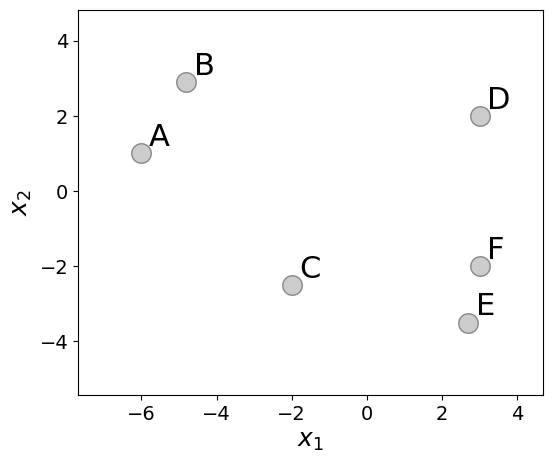

In [3]:
X = np.array([(-6,1), (-4.8,2.9), (-2,-2.5), (3,2), (2.7,-3.5), (3,-2)])

plot_clusters(X)    

Before we look in the AGNES algorithm in more detail, let's utilize the [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) class of [scikit-learn](https://scikit-learn.org/) library for computing the cluster hierarchy and plotting the dendrogram for our example dataset.

**Important:** To construct a dendrogram, the complete hierarchy of cluster merges must be available. Therefore, when using [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html), the algorithm must be configured with `n_clusters=None` and `distance_threshold=0`. Setting `n_clusters=None` instructs the algorithm not to stop after reaching a predefined number of clusters but instead to continue merging until all observations have been combined into a single cluster, thereby constructing the full clustering hierarchy. At the same time, `distance_threshold=0` forces the algorithm to compute and store the distance associated with every merge in the `distances_` attribute. These merge distances, together with the merge history stored in `children_`, are required to construct the linkage matrix used by SciPy's `dendrogram` function &mdash; you can check out the implementation of the auxiliary method `plot_dendrogram()` we provide. If a fixed number of clusters is specified instead, the agglomerative process terminates early, leaving the hierarchy incomplete and preventing the dendrogram from representing the full clustering structure.

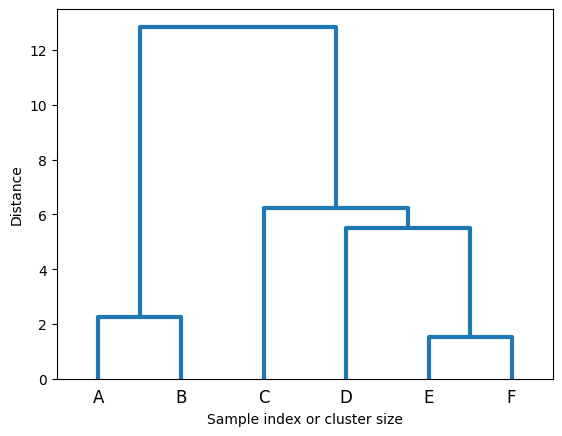

In [4]:
clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=0).fit(X)

plot_dendrogram(clustering, lw=3, color_threshold=0, labels=["A", "B", "C", "D", "E", "F"])

The dendrogram tells us that clusters $E$ and $F$ are closest and therefore get merged first &mdash; we can also see this in the raw data distribution above. The next two closest clusters are $A$ and $B$. We can also see that the distance between $E$ and $F$, and between $A$ and $B$ are quite similar, since the heights of the vertical lines represent that these two merges are quite similar. The third merge is between clusters $EF$ and $D$, followed by clusters $DEF$ and $C$, and lastly clusters $AB$ and $CDEF$. Again, based on the heights of the merges, we can deduce that clusters $AB$ and $CDEF$ a fairly well separated.

An important advantage of a dendrogram is that its visualization is independent of the dimensionality of the dataset. Unlike scatter plots, which are naturally limited to two or three dimensions and often require dimensionality reduction techniques (e.g., PCA or t-SNE) to visualize high-dimensional data, a dendrogram represents only the hierarchical relationships between observations. It displays the sequence in which clusters are merged and the corresponding linkage distances, regardless of whether the original data contains two features or thousands. Consequently, a dendrogram preserves the complete hierarchical structure of the clustering without introducing distortions that may arise from projecting high-dimensional data into a lower-dimensional space.

On the flip side, it is easy to see that dendrograms have practical limitations when applied to large datasets. As the number of observations increases, the number of leaf nodes and branches grows proportionally, causing the diagram to become increasingly crowded and difficult to interpret. Labels may overlap, individual branches become indistinguishable, and the hierarchical structure is obscured by visual clutter. Although the underlying hierarchical clustering can still be computed, the dendrogram itself loses much of its explanatory value for datasets containing hundreds or thousands of observations. Consequently, dendrograms are most effective for small to moderately sized datasets, while alternative visualization techniques or summary representations are often preferred for larger datasets.

That being said, hierarchical clustering is generally not applied to very large datasets because of its relatively high computational and memory requirements. AGNES requires the computation and storage of pairwise distances between observations, leading to memory requirements that grow quadratically with the number of data points. In addition, the repeated merging of clusters makes the algorithm computationally more expensive than many partitional clustering methods, such as K-Means. As a result, hierarchical clustering is typically best suited for small to moderately sized datasets, whereas algorithms with better scalability are generally preferred for large-scale data analysis.

---

## The AGNES Algorithm

### Basic Approach

Hierarchical clustering can be performed in two ways: **agglomerative (bottom-up)** or **divisive (top-down)**. In agglomerative clustering, each data point starts as its own cluster, and the algorithm repeatedly merges the most similar clusters until a stopping criterion is reached. In divisive clustering, all data points start in a single cluster, which is then recursively split into smaller clusters. AGNES (AGglomerative NEStin, as its name suggests, is an agglomerative (bottom-up) hierarchical clustering algorithm. The core idea of the algorithm is very straightforward:

* **Initialization.** Each data point starts out as its own cluster. This trivial set of clusters is the bottom clustering of the result hierarchy of clusterings.

* **Iterative merging.** For a latest set of clusters (i.e., the currently highest clustering in the hierarchy), perform the following steps:

    * Find the two clusters closest to each other with respect to the given distance metric (e.g., Euclidean distance)
    * Merge these two clusters into a new cluster to get the next higher clustering in the hierarchy
    * Stop if only $1$ cluster remains (for the full hierarchy) or if the specified number of clusters has been reached

Although this process seems very straightforward, there is one ambiguity that needs to be addressed. Essentially all distance metrics such as the Euclidean Distance are defined to compute the distances between pairs of data points. This works just fine for the very first merge since at this point all clusters contain only a single data point. In other words, computing the distance between two clusters is the same as computing the distance between two data points. But again, this is only for the very first merge.

In general, clusters contain more than one data point in which case it is not obvious how to compute distances between them. In fact, various meaningful approaches exist to compute the distances between sets of data points (i.e., clusters). These different approaches are called **linkage methods**, and we need to introduce them before implementing the AGNES algorithm.

### Linkage Methods

In hierarchical clustering, **linkage methods** define how the distance between two clusters is measured when deciding which clusters to merge at each step of an agglomerative algorithm such as AGNES. Different linkage methods use different criteria, leading to different cluster shapes and structures; as we will see later. Depending on the dataset, the choice of linkage method can have a significant impact on the resulting hierarchical clustering and dendrogram.

To provide a better intuition, we use another small $2$-dimensional dataset showing a set of $3$ clusters. Let's first load the data from the file into a Pandas DataFrame. Notice that the DataFrame has a column `Y` with values $0..2$ to indicate to which of the $3$ clusters each data point belongs.

In [5]:
df = pd.read_csv(demo_data_linkage)

df.head()

,X1,X2,Y
0,-1.82,3.57,0
1,-0.81,3.14,0
2,-0.73,3.66,0
3,-1.88,5.02,0
4,-1.05,2.78,0


We can now visualize the data by first converting the DataFrame into NumPy arrays and use the provided auxiliary method `plot_linkage_example` to plot all data points; the colors indicate the clusters.

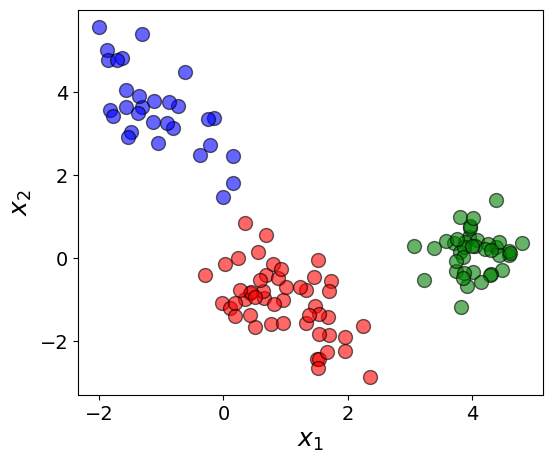

In [6]:
X_linkage, y = df[["X1", "X2"]].to_numpy(), df[["Y"]].to_numpy()

plot_linkage_example(X_linkage, y)

If we assume that these $3$ clusters represent the clustering after the most recent merge, we now have to decide which are the next $2$ clusters that should be merged. Think about which clusters you would merge next! For example, if we could merge the $Blue$ and the $Red$ cluster because they are very close, at least with respect to some of their data points. However, the resulting cluster would be very large. In contest, if we would merge the $Red$ and the $Green$ cluster, the resulting cluster would be a bit more compact.

In short, different alternatives favor different characteristics, and there is generally no single best answer to this question which clusters should be merged next. The choice of linkage method species which merges should be favoured, which can lead to very different results in practice. In the following, we cover the most common linkage method, and later we will compare their behavior using various example datasets.

#### Single Linkage

Single Linkage computes the distance between two clusters as the minimum distance between any two points from each cluster. Thus, we assume two clusters $C_1$ and $C_2$, their distance $d_{single}$ using Single Linkage is defined as:

$$\large
d_{single}(C_1, C_2) = \underset{p\in C_1,\ q\in C_2}{min}d(p, q)
$$

where $d(p, q)$ is any pointwise distance metric such as the Euclidean Distance. Of course, from all pairwise distances between clusters, we then pick the smallest distance to find the cluster pair we merge next. It is arguably easy to see that Single Linkage will merge the $Blue$ and $Red$ cluster next as the distance between their closest data points is smallest compared to the remaining pairs of clusters. 

We can also visualize the idea behind Single Linkage using the method `plot_linkage_example()`. When setting the input argument `method` to use Single Linkage, the method finds for each pair of clusters the two data points closest to each other. It then draws a double-headed arrow between these two data points.

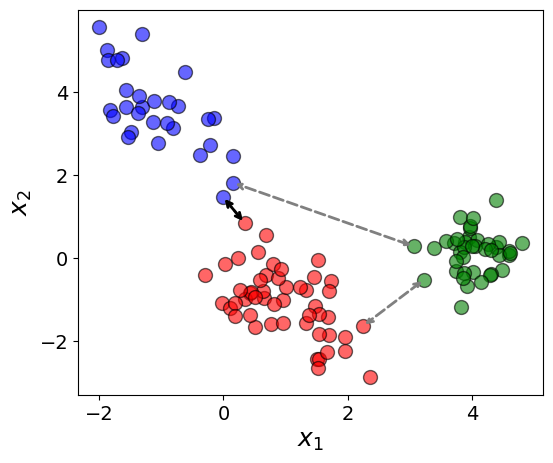

In [7]:
plot_linkage_example(X_linkage, y, method="single")

Since we have $3$ clusters, we also have $3$ pairs of clusters, each given as a pair of data points representing the shortest distance between two clusters with respect to Single Linkage. The plot above confirms our expectation that $Blue$ and $Red$ clusters are closest to each other; again, when assuming Single Linkage.

#### Complete Linkage

Complete Linkage is kind of the "opposite" of Single Linkage: instead of considering the smallest distances between any two data points of two clusters, Complete Linkage considers the largest distance between any two data points. This penalizes pairs of clusters that would merge to form a very large cluster. Mathematically, the distance $d_{complete}$ between two clusters using Complete Linkage is defined as:

$$\large
d_{complete}(C_1, C_2) = \underset{p\in C_1,\ q\in C_2}{max}d(p, q)
$$

Again, each pair of clusters yields a distance, and we pick the pair with the smallest distance to merge next. Using the method `plot_linkage_example()` we can plot the data together with cluster distances as the largest distances between any data points across both clusters.

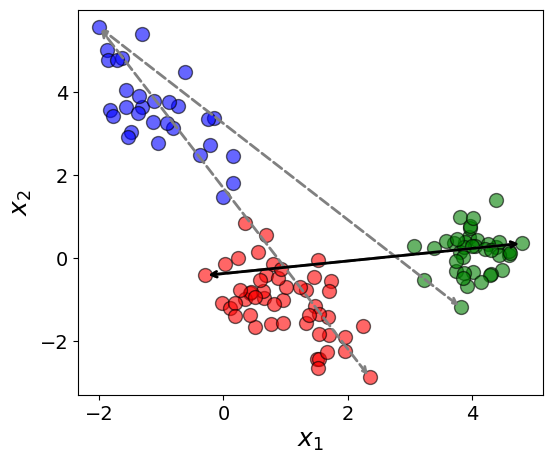

In [8]:
plot_linkage_example(X_linkage, y, method="complete")

Although the $Blue$ and $Red$ clusters seem close, since they are both elongated, their distance according to Complete Linkage is rather large. Here the smallest distance between two clusters is now between the $Red$ and the $Green$ clusters; thus, these two clusters would be merged next when using Complete Linkage.

#### Average Linkage

Between Single Linkage ($min$) and Complete Linkage ($max$) we have Average Linkage. As the name suggests, Average Linkage compute the distance between two clusters as the average distance across all pairs of data points of the two clusters, i.e.:

$$\large
d_{average}(C_1, C_2) = \underset{p\in C_1,\ q\in C_2}{avg}d(p, q)
$$

Average Linkage provides a compromise between the behaviors of Single Linkage and Complete Linkage. While Single Linkage merges clusters based on the closest pair of points, making it sensitive to chaining effects &mdash; explained and illustrated later &mdash; Complete Linkage relies on the farthest pair of points, often producing overly compact clusters. Average Linkage instead considers the average distance between all pairs of points across two clusters, balancing local proximity with overall cluster cohesion. As a result, it is generally less susceptible to chaining than Single Linkage while avoiding the excessive sensitivity to outliers characteristic of Complete Linkage.

In contrast to Single and Complete Linkage, the distances based on Average Linkage cannot be associated to specific pairs of data points across two clusters. There is therefore no meaningful way to plot the distance the way we could for Single and Complete Linkage (see above).

#### Ward Linkage

Single, Complete, and Average Linkage all define the distance between clusters using pairwise point distances, but each has characteristic limitations. Single Linkage is prone to the *chaining effect*, where clusters become connected through a sequence of nearby points, often resulting in elongated and poorly separated clusters. Complete Linkage avoids chaining by considering the maximum pairwise distance, but it is sensitive to outliers and tends to produce overly compact, spherical clusters. Average Linkage offers a compromise by using the average pairwise distance between clusters, reducing both chaining and sensitivity to extreme points. However, it still relies solely on inter-point distances and does not explicitly optimize any global clustering objective, so its performance may degrade when clusters have varying sizes, densities, or shapes.

Ward Linkage takes a fundamentally different approach by viewing clustering as an optimization problem rather than a distance-based heuristic. At each step, it merges the pair of clusters that leads to the smallest increase in the total within-cluster variance (or equivalently, the smallest increase in the sum of squared errors). This criterion favors merges that preserve cluster homogeneity, typically resulting in compact and relatively balanced clusters. While Ward Linkage often produces high-quality partitions for numerical data, it is best suited to Euclidean distances and tends to perform less well when the true clusters are highly elongated or irregularly shaped.

$$\large
d_{ward}(C_1, C_2) =
\frac{n_1 n_2}{n_1+n_2}
\lVert
\boldsymbol{\mu}_1-\boldsymbol{\mu}_2
\rVert ^2,
$$

where  $n_1 = |C_1|$ and $n_2 = |C_2|$ are the cluster sizes, $\boldsymbol{\mu}_1$ and $\boldsymbol{\mu}_2$ be the corresponding cluster centroids (e.g., the average of all data points within each cluster when using the Euclidean distance), and $\lVert \cdot \rVert$ denotes the Euclidean norm. A mathematically equivalent expression for the Ward distance is:

$$\large
d_{ward}(C_1, C_2) = \text{WCSS}(C_1 \cup C_2) - \text{WCSS}(C_1) - \text{WCSS}(C_2)
$$

where $\text{WCSS}(C) = \sum_{\mathbf{x}\in C} \lVert\mathbf{x}-\boldsymbol{\mu}_C\rVert ^2$ is the within-cluster sum of squares for a cluster $C$. This expression arguably shows better that Ward Linkage merges the pair of clusters by minimizing the increase in within-cluster variance at each step. However, the first formula is the computationally efficient closed-form expression for the second and is the one most commonly used in practice.

Like for Complete Linkage, we cannot directly plot Ward distances since they are not directly associated with pairs of data points. However, we provide the auxiliary method `plot_linkage_comparison()` that computes AGNES with a specific target number of clusters `n_clusters` using all $4$ linkage methods and plots the results. Since we assume that we start with $3$ clusters and are curious about the next merge, we need to set `n_clusters=2`.

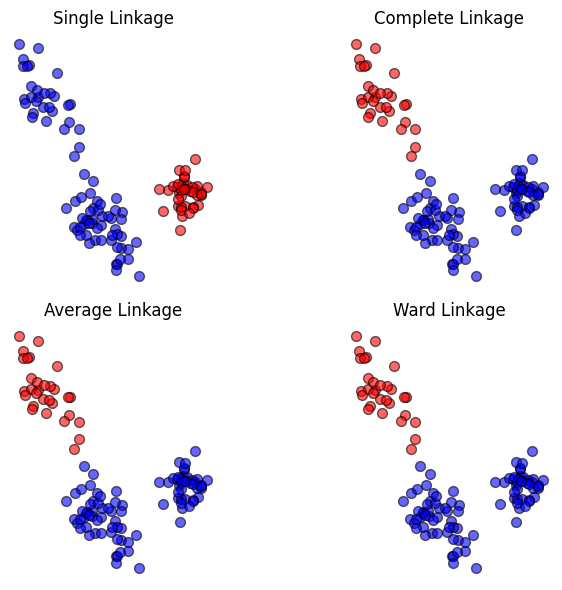

In [9]:
plot_linkage_comparison(X_linkage, n_clusters=2)

We will use the method `plot_linkage_comparison()` later when exploring the behavior of AGNES across different types of datasets and across all $4$ linkage methods. For this example, Single Linkage is the only method that merges the initial $Blue$ and $Red$ clusters. All other linkage methods add more emphasis on generating more compact clusters, thus preferring to merge the initial $Red$ and $Green$ clusters.

To sum up, the choice of linkage method is a critical factor in hierarchical clustering algorithms such as AGNES, as it directly influences the structure and quality of the resulting clusters. No single linkage criterion is universally optimal; the most suitable method depends on the characteristics of the dataset and the objectives of the clustering task. In practice, selecting an appropriate linkage strategy often requires comparing the clusterings produced by different methods and evaluating which best captures the underlying data structure or meets the desired application-specific criteria. We will provide such comparisons for various example datasets later to give a general idea how the different linkage methods behave.

---

### A Simple Implementation

We saw that, once we can quantify the distance between two clusters (i.e., the distance between two sets of data points), the basic AGNES algorithm is rather straightforward. This includes that we can quite easily implement at least a simple version of the algorithm from scratch in Python. So let's just do this.

**Important:** The implementation we cover below is very basic. Firstly, we ignore any efficiency concerns and optimization strategies, meaning that our code is likely to perform poorly on large(r) datasets. And secondly, we only focus on the merging of clusters but omit keeping track of all the details (e.g., distance information) needed to draw dendrograms. The reason for this is to keep the implementation as simple as possible.


#### Core Methods

We already know that the iterative process of AGNES requires the two steps of computing the distances between pairs of clusters and merging the two closest clusters into a new cluster. Let's start by implementing the computation of the distance between two clusters. Since we want to support the different Linkage methods, we define a constant for each method to improve the readability and use of the code.

In [10]:
LINKAGE_SINGLE   = 0
LINKAGE_COMPLETE = 1
LINKAGE_AVERAGE  = 2
LINKAGE_WARD     = 3

The `compute_cluster_distance()` method computes the distance between two clusters of data points. The function takes the dataset `X`, two clusters `c1` and `c2` &mdash; note that both clusters are represented as a list of indices pointing to data points in `X`; this is why we use `X[c1]` and `X[c2]` to index the actual data points of the clusters.

Since the Ward Linkage does not require to compute the pairwise distances between data points, we can handle this linkage method separately by implementing the closed-form expression we have seen above 1:1 in Python with the help of NumPy. For all other linkage methods, we use the [`euclidean_distances()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.euclidean_distances.html) method of the [scikit-learn](https://scikit-learn.org/) library. This produces a matrix containing all pairwise distances between the two clusters. For Single, Complete, and Average Linkage methods we can therefore simply use the built-in methods `min()`, `max()`, and `avg()` of NumPy.

In [11]:
def compute_cluster_distance(X, c1, c2, linkage=LINKAGE_AVERAGE):
    X1, X2 = X[c1], X[c2]
    
    # Compute all pairwise distances using Euclidean distance
    if linkage == LINKAGE_WARD:
        n1, n2 = len(c1), len(c2)
        mu1, mu2 = np.mean(X1, axis=0), np.mean(X2, axis=0)
        squared_centroid_distance = np.sum((mu1 - mu2) ** 2)
        return (n1 * n2) / (n1 + n2) * squared_centroid_distance        

    # All other linkage methods need the pairwise distances between data points
    distances = euclidean_distances(X[c1], X[c2])
            
    # Calculate and return the final distance w.r.t. the specified linkage criteria
    if linkage == LINKAGE_SINGLE:
        return np.min(distances)
    elif linkage == LINKAGE_COMPLETE:
        return np.max(distances)
    elif linkage == LINKAGE_AVERAGE:
        return np.mean(distances)
    else:
        raise ValueError("Unknown linkage method.")

To test this method, we can compute the distances between two clusters. In the code cell below, both clusters contain $2$ data points (more specifically, their indices with respect to `X`). Which data points we choose is not really relevant just for testing the method. However, in practice, the two clusters will always be disjoint.

In [12]:
for linkage in [LINKAGE_SINGLE, LINKAGE_COMPLETE, LINKAGE_AVERAGE, LINKAGE_WARD]:
    distance = compute_cluster_distance(X, [1,2], [3,4], linkage=linkage)
    print(f"Linkage method {linkage}: {distance:.2f}")

Linkage method 0: 4.81
Linkage method 1: 9.86
Linkage method 2: 7.31
Linkage method 3: 39.97


We can make two main observations from this output:

* Unsurprisingly &mdash; excluding Ward Linkage &mdash; Single Linkage ($0$) yields the shortest distance, Complete Linkage ($1$) the largest distance, and Average Linkage ($2$) falls in between. This derives directly from the $min$, $max$, and $avg$ operations of those linkage methods.

* The result of the Ward Linkage ($3$) "stands out" because its value does not relate to any pairwise distances between data points but measures the increase in within-cluster variance. Of course, for each linkage method, we only care about the relative differences in the distances and not their absolute values.

To find the two clusters with the minimum distance, we now have to compute the distances between all pairs of clusters. The method `compute_distance_matrix()` in the code cell below implements this by generating a matrix containing all pairwise distances. Since we are looking for the minimum distance, we initialize the matrix with $+\infty$. The nested loop generates all pairs of clusters, and for each pair we use the method `compute_cluster_distance()` to compute and update the value for the distance matrix. 

Of course, because the Euclidean distance is symmetric, the full distance matrix is symmetric as well. We can therefore speed up the implementation by only considering the value above or below the main diagonal &mdash; we can also ignore the main diagonal entries since we never merge a cluster with itself. All entries of the distance matrix we ignore remain $+\infty$ and therefore do not affect finding the pair of clusters with the minimum distance.

In [13]:
def compute_distance_matrix(X, clusters, linkage=LINKAGE_AVERAGE):
    # We initialize the distance matrix with all elements set to INFINITY
    # Since we look for the minimum and do not need to calculate all values
    # (recall that the distance matrix is symmentrical)
    distance_matrix = np.full((len(clusters), len(clusters)), np.inf)
    
    # Nested loop to calculate distances between all pairs of clusters
    for idx1, c1 in enumerate(clusters):
        for idx2, c2 in enumerate(clusters):
            # Ignore values on the diagonal and lower triangual matrix
            if idx1 >= idx2:
                continue

            # Calculate the distance between two clusters given specified metric
            cluster_distance = compute_cluster_distance(X, c1, c2, linkage=linkage)
            
            # Update distance value in the distance matrix
            distance_matrix[idx1][idx2] = cluster_distance
    
    return np.array(distance_matrix)

For testing the method, we need a set of clusters. In the code cell below, we perform the initialization steps, where each data point forms its own cluster. This is our first clustering on the lowest level of the clustering hierarchy. We can simply achieve this, by creating a column vector of size $n$ (with $n$ being the number of data points) and the values of range $0..(n\!-\!1)$ (representing the indices of all data points).

In [14]:
clusters1 = np.arange(len(X)).reshape(-1,1)

print(clusters1)

[[0]
 [1]
 [2]
 [3]
 [4]
 [5]]


Using this first set of clusters, we can now compute the first distance matrix using the method `compute_distance_matrix()`; if we do not provide the `linkage` argument, the method applies Average Linkage by default. The output is the distance matrix as a $2$-dimensional NumPy array which we can directly print to inspect the values.

In [15]:
distance_matrix1 = compute_distance_matrix(X, clusters1)

with np.printoptions(precision=2):
    print(distance_matrix1)

[[ inf 2.25 5.32 9.06 9.79 9.49]
 [ inf  inf 6.08 7.85 9.86 9.21]
 [ inf  inf  inf 6.73 4.81 5.02]
 [ inf  inf  inf  inf 5.51 4.  ]
 [ inf  inf  inf  inf  inf 1.53]
 [ inf  inf  inf  inf  inf  inf]]


Although this output shows all the important information, we also provide an auxiliary method `plot_distance_matrix()` which converts the NumPy array to a Pandas DataFrame. This allows for a more convenient representation of the distance matrix since we can also show the cluster labels; and overall, this representation is much more readable than the raw NumPy array.

In [16]:
df = plot_distance_matrix(distance_matrix1, clusters1)

df.head(len(distance_matrix1))

,A,B,C,D,E,F
A,,2.25,5.32,9.06,9.79,9.49
B,,,6.08,7.85,9.86,9.21
C,,,,6.73,4.81,5.02
D,,,,,5.51,4.0
E,,,,,,1.53
F,,,,,,


When looking at this data matrix, we can see that clusters $E$ and $F$ are closest with a distance of $1.53$ (using Average Linkage). You can check with the plot of the dataset above, the points $E$ and $F$ are indeed the two data points closest to each other.

**Side note:** For this first clustering where each data point forms its own cluster, Single Linkage, Complete Linkage, and Average Linkage will all return the same distance matrix. After all, in this case, the distance between two clusters is completely determined by the distance between the two respective data points; and the $min$, $max$, and $avg$ of a set containing only one value is of course only that value.

Now that we know that two closest clusters, we need to merge them to get the next clustering of the hierarchy. This new clustering is simply the previous set of clusters &mdash; excluding the two clusters we need to merge! &mdash; and the newly merged cluster. The method `merge()` in the code cell below implements this process. Note that the method using the NumPy method [`unravel_index()`](https://numpy.org/doc/stable/reference/generated/numpy.unravel_index.html) to conveniently find the row and column index of the distance matrix holding the value of the minimum distance.

In [17]:
def merge(clusters, distance_matrix):
    # Get the row and column index of the minimum distance
    # These two indices represent the 2 cluster we need to merge
    # (we assume there's only one pair of cluster with minimum distance)
    c1, c2 = np.unravel_index(distance_matrix.argmin(), distance_matrix.shape)

    # Initialize the new set of clusters as the old cluster without the ones we merge
    new_clusters = [ c for idx, c in enumerate(clusters) if idx not in [c1, c2] ]

    # Merge the two closes clusters and them to the new clustering
    new_clusters.append(np.concatenate((clusters[c1], clusters[c2]), axis=0))
    
    return new_clusters

Let's create the next clustering by merging clusters $E$ (index $4$) and $F$ (index $5$) using the `merge()` method and providing the current clustering and the respective distance matrix.

In [18]:
clusters2 = merge(clusters1, distance_matrix1)

print(f"New clustering: {clusters2}")

New clustering: [array([0]), array([1]), array([2]), array([3]), array([4, 5])]


Having implemented the computation of the distance matrix (including the computation of the distance between two clusters supporting different linkage methods) and the merging step, we have all the core methods for the AGNES algorithm. To show this, we can compute and plot the next distance matrix using the new clustering after the first merge.

In [19]:
distance_matrix2 = compute_distance_matrix(X, clusters2)

df = plot_distance_matrix(distance_matrix2, clusters2)

df.head(len(distance_matrix2))

,A,B,C,D,EF
A,,2.25,5.32,9.06,9.64
B,,,6.08,7.85,9.54
C,,,,6.73,4.92
D,,,,,4.75
EF,,,,,


In this representation $EF$ represents the clusters after merging the initial clusters $E$ and $F$. Now that we have our first cluster containing more than one data point, the distance matrix will generally differ depending on the choice of linkage method. Either way, based on the distance matrix, we can find the next two closest clusters and merge them to get the third clustering for our hierarchy.

In [20]:
clusters3 = merge(clusters2, distance_matrix2)

print(f"New clustering: {clusters3}")

New clustering: [array([2]), array([3]), array([4, 5]), array([0, 1])]


The data points and indices $0$ and $1$ represent the point labeled $A$ and $B$ in the plot of the dataset; see above. 

Of course, we could keep "manually" calling `compute_distance_matrix()` and `merge()` until we get a clustering containing a single cluster with all the data points, in which case we are done. 

#### Full Algorithm

In the previous section, we implemented all core steps of the AGNES algorithm in terms of their own methods. We also saw how to alternatively call those methods to generate the next clustering in the hierarchy. All that is remaining is to combine all these steps into a single method, as implemented by the method `agnes()` in the code cell below. This method essentially combines initializing the first set of clusters (i.e., each data point forming its own cluster) and then iteratively computes the distance matrix and merge the two cluster clusters. Here some additional explanations:

* The list `cluster_hierarchy` keeps track of all the clustering of the hierarchy; thus, `cluster_hierarchy[-1]` references the most recent clustering after the last merge

* The list `label_hierarchy`keeps track of all the clusterings as well; however, while `cluster_hierarchy` is for eternal use, the format of the lists of labels match the format used by [scikit-learn](https://scikit-learn.org/). For example, a list of `[1, 0, 2, 1, ...]` means that the 1st data point belongs to cluster $1$, the 2nd data point belongs to cluster $0$, the third data point belongs to cluster $2$, and so on. Again, we do not really need this representation but it allows to reuse the same plotting methods to visualize the result from our own implementation of AGNES and the one provided by [scikit-learn](https://scikit-learn.org/)

* Also in line with the ANGES implementation of [scikit-learn](https://scikit-learn.org/), the method accepts as input arguments the number of clusters $n_clusters$. If this value is set to $None$, method `agnes()` computes the complete clustering hierarchy; otherwise it stops early when the specified number of clusters have been reached.

In [21]:
def agnes(X, n_clusters=2, linkage=LINKAGE_AVERAGE):
    cluster_hierarchy = []
    label_hierarchy = []
    
    # In the initial state, all data points form their own cluster
    clusters = np.arange(len(X))

    # Add initial cluster as first solution to the cluster hierarchy
    cluster_hierarchy.append(clusters.reshape(-1,1))
    label_hierarchy.append(clusters)

    if n_clusters is None:
        threshold = 1
    else:
        threshold = n_clusters
        
    # Combine the nearest clusters as long as there a more than 1 cluster
    while len(cluster_hierarchy[-1]) > threshold:
        # Get the last cluster distribution
        clusters = cluster_hierarchy[-1]
        
        # Calculate the distance matrix
        distance_matrix = compute_distance_matrix(X, clusters, linkage=linkage)

        # Generate new clustering by merging the two closest clusters
        new_clusters = merge(clusters, distance_matrix)
    
        # Add new cluster distribution to the cluster hierarchy
        cluster_hierarchy.append(new_clusters)

        # Create labels for each hierachy label to mimic output of of scikit-learn implementation
        labels, cluster_id = [-1]*len(X), 0
        for cluster in new_clusters:
            for idx in cluster:
                labels[idx] = cluster_id
            cluster_id += 1
        label_hierarchy.append(labels)
            
    return np.asarray(label_hierarchy)

Let's compute the complete hierarchy of cluster labels for our small example dataset using the method `agnes` and print the result. By setting `n_clusters=None`, we make `agnes()` compute the full hierarchy.

In [22]:
label_hierarchy = agnes(X, n_clusters=None)

print(f"Hierarchy of cluster labels (lowest level is on top):\n{label_hierarchy}")

Hierarchy of cluster labels (lowest level is on top):
[[0 1 2 3 4 5]
 [0 1 2 3 4 4]
 [3 3 0 1 2 2]
 [1 1 0 2 2 2]
 [0 0 1 1 1 1]
 [0 0 0 0 0 0]]


Each row on the output above represents a clustering starting with the lowest level where each data point forms its own cluster; hence the $6$ different cluster labels $0..5$. After each merge, the total number of clusters naturally decreases by $1$ since we merge the two closest clusters in each iteration. Since we set `n_cluster=None`, method `agnes()` computes the complete hierarchy until all data points are grouped into a single cluster.

Apart from just printing this $2$-dimensional array, we can also use the `plot_cluster()` method to visualize each clustering across all hierarchy levels; after all, we only have $6$ levels in the full hierarchy. Keep in mind, however, that these plots are "independent" with respect to the colors of the data points, i.e., the colors are not guaranteed to be preserved after merging clusters. The colors of data points indicate points belonging to the same cluster with respect to each individual plot.

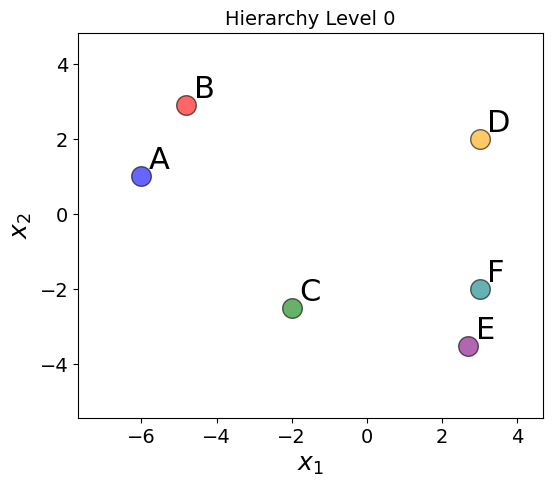

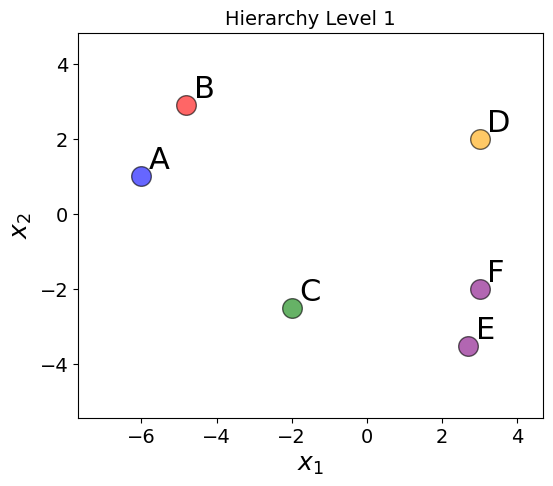

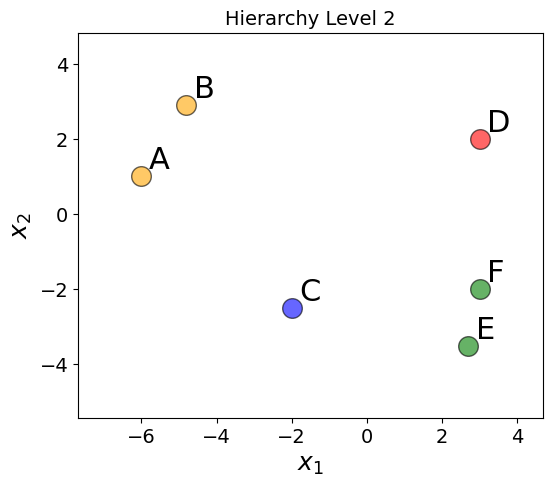

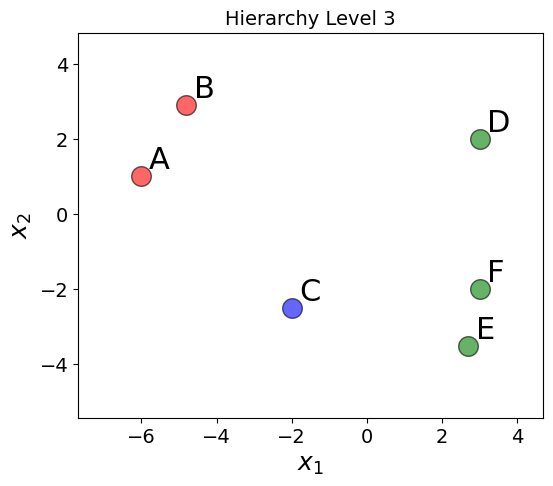

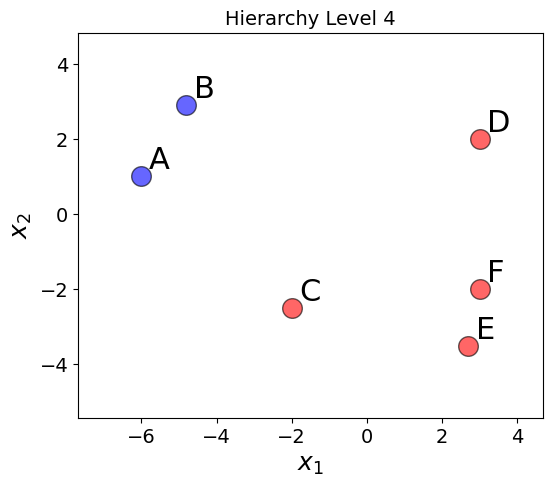

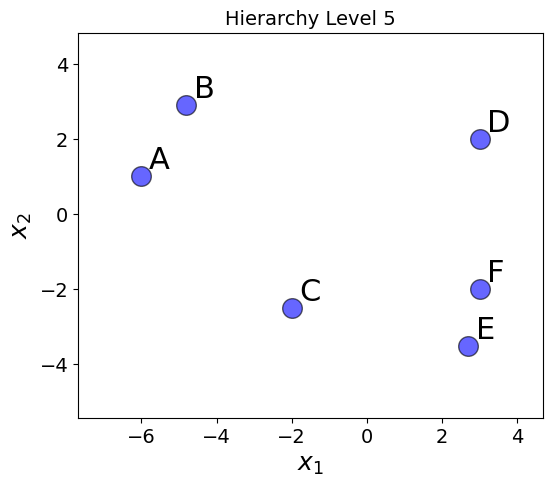

In [23]:
for level in range(len(label_hierarchy)):
    plot_clusters(X, labels=label_hierarchy[level], level=level)

Of course, assuming the full clustering hierarchy, all data points in the last plot have the same color since the last clustering contains only a single cluster with all the data points assigned to it.

**Important:** Recall the method `agnes()` is limited to the basic steps and does not maintain enough information to support the plot of a dendrogram. However, those are mainly just bookkeeping information, and the goal was to implement the AGNES algorithm as light-weight and as easy to follow as possible.

You are strongly encouraged to go back and run method `agnes()` with different linkage methods and different values for `n_clusters` to see how the choice of values affects the results. Of course, the descriptions of the results refer to the results based on the default parameters.

---

## Comparison of Linkage Methods

To better understand the characteristics of the different linkage methods, it is helpful to compare their behavior on a variety of example datasets. While the definitions of Single, Complete, Average, and Ward Linkage are relatively straightforward, their practical effects on the clustering process are often less intuitive. Visualizing how each method merges clusters on the same dataset provides valuable insight into the influence of the chosen linkage criterion on the resulting cluster hierarchy.

Although the example datasets considered in the following are intentionally simple and somewhat artificial, they are designed to highlight specific strengths and weaknesses of the different linkage methods. By isolating particular geometric configurations, these examples make it easier to observe phenomena such as the chaining effect of Single Linkage, the compact clusters produced by Complete Linkage, the balanced behavior of Average Linkage, and the variance-minimizing nature of Ward Linkage. As a result, they provide a useful foundation for understanding how the choice of linkage method affects clustering performance on more complex real-world datasets.

All the following example datasets are $2$-dimensional to allow for easy plotting. We start with a dataset featuring $3$ circular regions of different sizes.

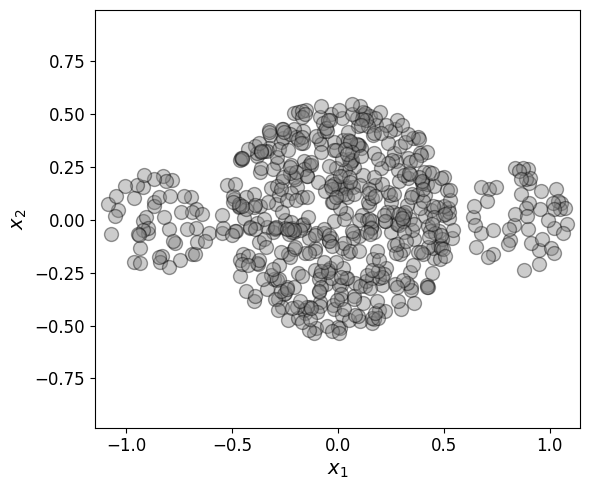

In [24]:
X_triple = pd.read_csv(demo_data_triple).to_numpy()

plot_data(X_triple)

Just by looking at the plot, one can arguably "see" $3$ clusters; of course, the notion of what constitutes a meaningful cluster is often rather subjective. But assuming there are $3$ clusters, we can check how AGNES using the different linkage method behaves, and any approach does indeed find the clusters as expected. The method `plot_linkage_comparison()` performs AGNES with all $4$ linkage method using the implementation of the [scikit-learn](https://scikit-learn.org/) library and plots all $4$ results as a single image.

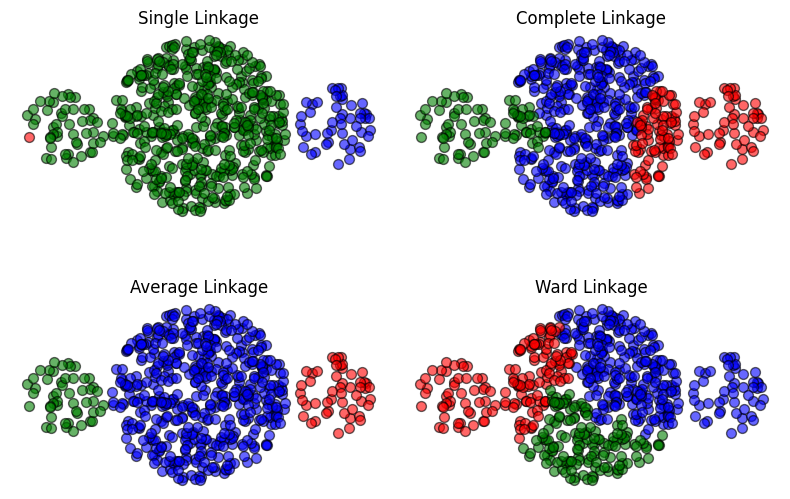

In [25]:
plot_linkage_comparison(X_triple, n_clusters=3)

A big surprise might be the resulting clustering for Single Linkage &mdash; notice that the 3rd cluster is an individual data point in the very left that is slightly further apart from the other data points. The issue here is that the two left "cluster-like" regions are so close together. Single linkage is susceptible to the **chaining effect**, where clusters are merged based solely on the distance between their closest pair of points. As a result, a sequence of nearby points can gradually connect otherwise well-separated groups, producing long, elongated clusters that may not reflect the true structure of the data. While this property enables Single Linkage to identify clusters with irregular or non-convex shapes, it also makes the method sensitive to noise and outliers, which can inadvertently act as bridges between distinct clusters.

For this example dataset, only Average Linkage returns the $3$ cluster we "see" in the dataset. I contrast, because Ward Linkage minimizes the increase in within-cluster variance, it has a bias toward clusters of similar size. When spherical clusters have substantially different sizes and are not well separated, Ward linkage may merge a smaller cluster into a nearby larger one before recognizing it as a distinct cluster. In contrast, average linkage is generally less affected by differences in cluster size because it bases decisions on the average pairwise distance between clusters rather than on the increase in cluster variance. As a result, Ward linkage can struggle to recover clusters of unequal sizes when they are close together, even if each cluster is approximately spherical.

Next, let's consider a dataset with distinctly non-spherical or non-globular clusters. More specifically, the distribution of this dataset shows two concentric circles.

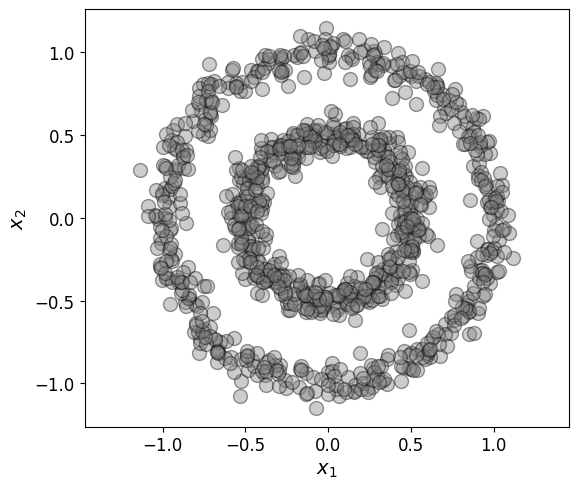

In [26]:
X_circles = pd.read_csv(demo_data_circles).to_numpy()

plot_data(X_circles)

Arguing again that we would like to get $2$ clusters that match both circles, let's apply AGNES and compare the different linkage methods.

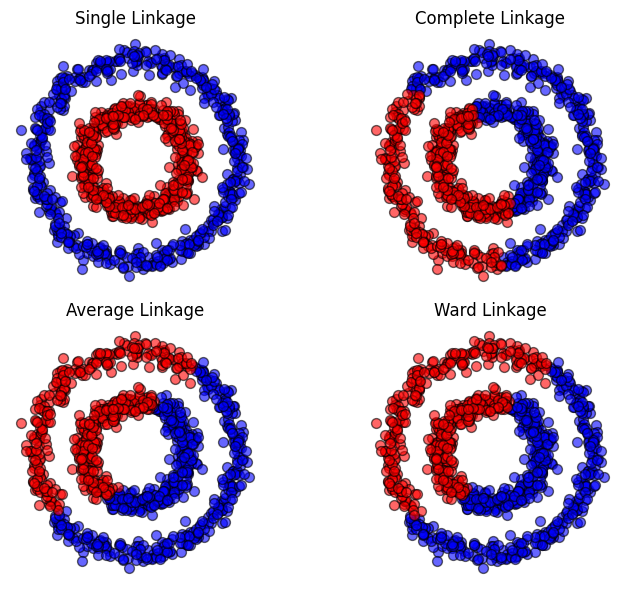

In [27]:
plot_linkage_comparison(X_circles, n_clusters=2)

Here, only Single Linkage accomplishes this task. Overall, only Single Linkage is capable of reliably recovering clusters with arbitrary, natural shapes. Since it defines the distance between two clusters as the minimum distance between any pair of points, it can gradually connect neighboring points along curved or elongated structures. This property allows Single Linkage to identify clusters that do not resemble compact blobs, such as crescents, rings, or winding manifolds.

In contrast, Complete, Average, and Ward Linkage all tend to favor compact, blob-like clusters. Although this trend often produces well-separated and robust clusters, they also have a tendency to split elongated or curved clusters into multiple smaller groups. Consequently, when the data contain naturally shaped clusters rather than approximately spherical ones, Single Linkage is typically the most appropriate choice despite its susceptibility to the chaining effect &mdash; which could have happened for our example dataset if there would have been a few datasets "connecting" the two rings.

Another popular example dataset featuring natural clusters is shown below, where the data distribution features two crescent shaped regions.

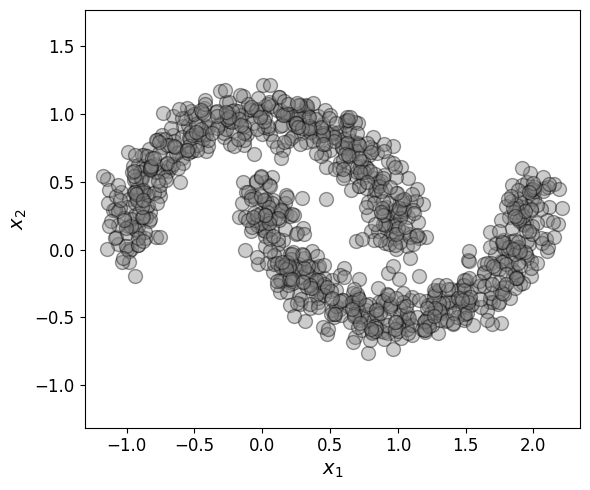

In [28]:
X_moons = pd.read_csv(demo_data_moons).to_numpy()

plot_data(X_moons)

If we apply AGNES with `n_clusters=2`, we get the following results.

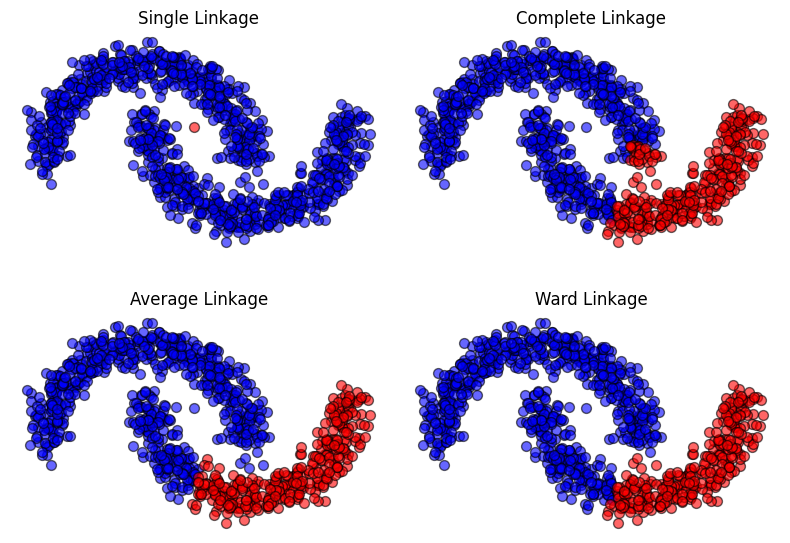

In [29]:
plot_linkage_comparison(X_moons, n_clusters=2)

As we now know, Complete, Average, and Ward linkage tend to break up natural clusters; and the results for this dataset confirm this.

However, even Single Linkage does not yield the expected clustering, and once again the reason for this is the chaining effect. Notice that both clusters are "connected" by a few data points at the left end of the upper crescent-shaped regions. In contrast, we have this single data point roughly in the middle that is far enough away from both regions so that Single Linkage considers this data point as its own clusters &mdash; and the two crescent-shaped regions collapse into a single cluster due to the chaining effect.

Let's switch back to spherical / blob-like clusters but now consider regions (i.e., potential clusters) of varying densities.

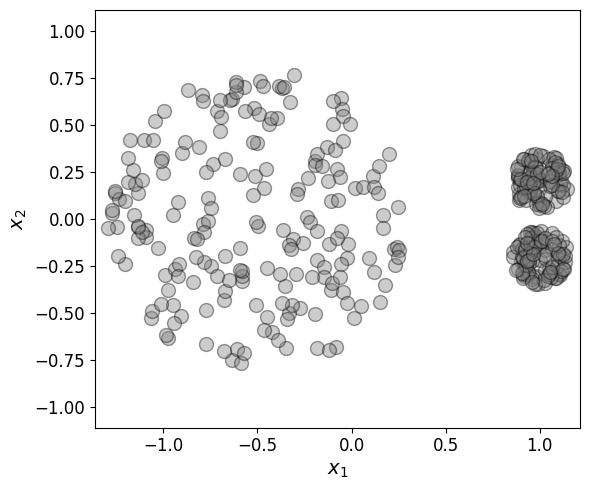

In [30]:
X_densities1 = pd.read_csv(demo_data_densities1).to_numpy()

plot_data(X_densities1)

Again, if asked how many clusters we see just by looking at the plot, we might say that this dataset contains $3$ clusters. Of course, the cluster on the left is a much less dense region than the $2$ clusters on the right. Once again, let's run AGNES with `n_clusters=3` and compare the results for the different linkage methods.

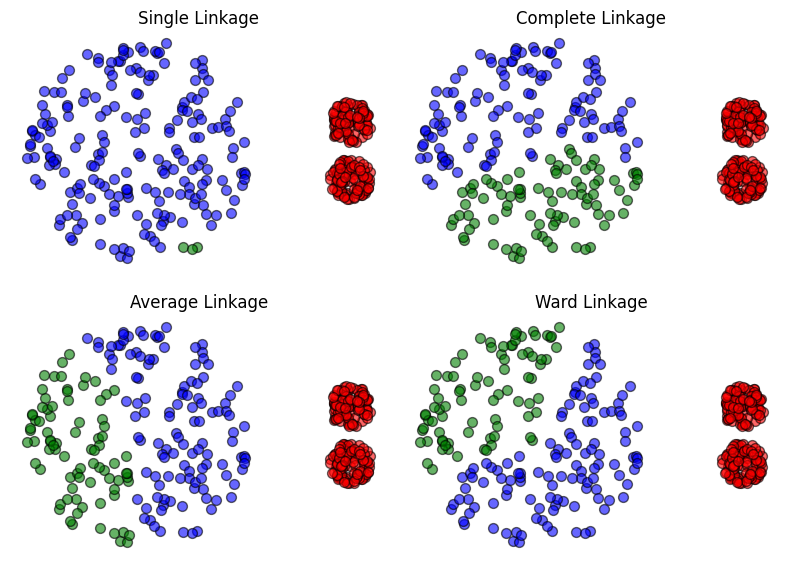

In [31]:
plot_linkage_comparison(X_densities1, n_clusters=3)

In general, hierarchical agglomerative clustering algorithms such as AGNES generally perform poorly on datasets containing clusters with substantially different densities because their merging decisions are based solely on distances between clusters. Dense clusters have many nearby points and are therefore merged quickly, whereas sparse clusters contain larger internal distances. As a result, the algorithm may merge a sparse cluster with a neighboring dense cluster before the sparse cluster has been fully formed, simply because the inter-cluster distances become smaller than the remaining intra-cluster distances within the sparse cluster.

This limitation affects all common linkage criteria, although to varying degrees. Single Linkage is particularly prone to connecting clusters through chains of nearby points, while Complete, Average, and Ward Linkage also rely on global distance measures that do not explicitly account for local point density. Since AGNES does not model density or distinguish between dense and sparse regions of the data, it cannot naturally adapt its merging strategy to clusters with varying densities. Consequently, datasets containing clusters of different densities are typically handled more successfully by density-based clustering algorithms such as DBSCAN or HDBSCAN, which explicitly incorporate local density into the clustering process.

A different kind of dataset with varying densities is shown below.

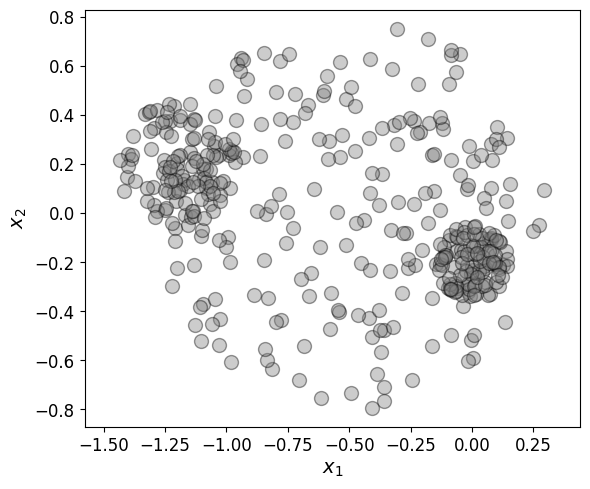

In [32]:
X_densities2 = pd.read_csv(demo_data_densities2).to_numpy()

plot_data(X_densities2)

Compared to the previous dataset, this dataset contains $2$ dense regions we arguably would like to see as clusters, whereas the remaining data points should not really belong to any of these $2$ clusters. However, we already know that AGNES is a complete cluster algorithm, meaning that all data points get assigned to clusters. Thus, we can already tell that running AGNES with `n_cluster=2` will not work as we would like to. So let's see what happens with `n_clusters=3`.

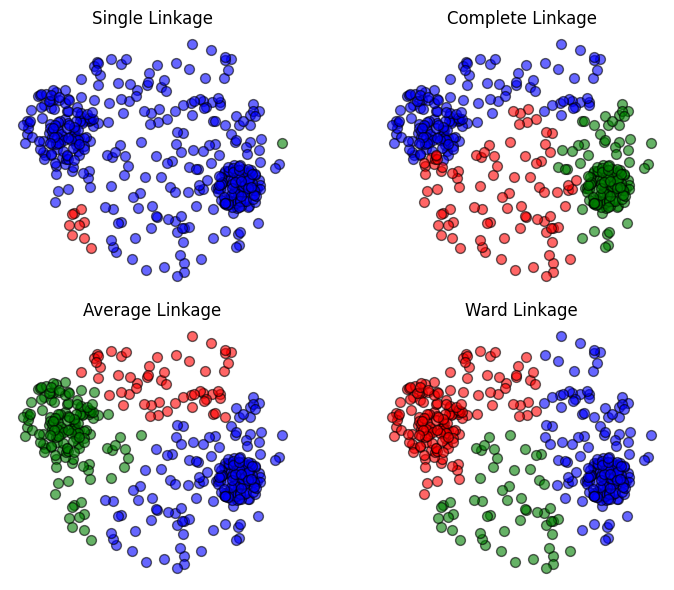

In [33]:
plot_linkage_comparison(X_densities2, n_clusters=3)

Once again, we can clearly see that AGNES has problems with clusters of different densities. This would be fine if AGNES would be able to treat data points in sparse regions as noise and not assigned to any clusters (e.g., like DBSCAN). However, since AGNES is complete, all the data points in the sparse regions are assigned to clusters. For this dataset, Single Linkage arguably performs worse, but the other linkage methods are also rather far away from our preferred results.

The last example dataset we consider contains $3$ spherical and well-separated regions and clearly should be returned as clusters (as always, arguably!)

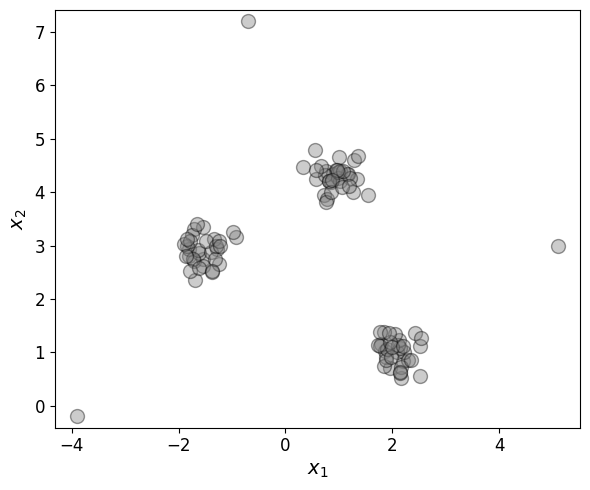

In [34]:
X_outliers = pd.read_csv(demo_data_outliers).to_numpy()

plot_data(X_outliers)

So one more time, let's run AGNES with `n_clusters=3` to see if and, if so, which linkage method meets our expectations for this dataset.

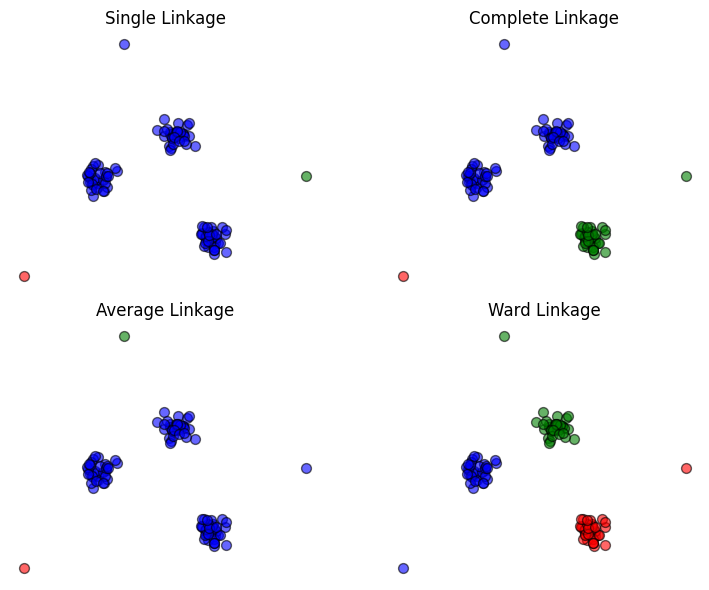

In [35]:
plot_linkage_comparison(X_outliers, n_clusters=3)

The different linkage methods also vary considerably in their sensitivity to outliers. However, the exact effects depend on the exact number and distribution of the outliers. As a consequence, the insights from the plots above cannot be generalized but only apply to the locations of these $3$ outliers. But in general, common observations are:

* Single linkage is generally the most susceptible because an outlier can act as a bridge between two otherwise distinct clusters, leading to the well-known chaining effect.

* Complete linkage is less affected by isolated outliers when determining which clusters to merge, but once an outlier becomes part of a cluster, it can substantially increase the cluster's maximum pairwise distance, delaying subsequent merges.

* Average linkage is typically more robust because it considers the average of all pairwise distances, causing the influence of a single outlier to be diluted by the many distances involving regular data points.

* Ward linkage is also relatively sensitive to outliers, although for a different reason. Since it minimizes the increase in within-cluster variance, an outlier contributes disproportionately to the cluster's sum of squared errors. Consequently, Ward linkage tends to keep outliers as singleton clusters until the later stages of the agglomeration process.

In short, the example datasets presented in this section illustrate how the choice of linkage method can have a significant impact on the resulting clustering. By considering datasets that emphasize different characteristics &mdash; such as compact clusters, irregularly shaped clusters, varying cluster sizes and densities, and the presence of outliers &mdash; it becomes easier to understand the strengths and weaknesses of single, complete, average, and Ward linkage. Although these datasets are intentionally simplified, they provide valuable intuition for how the different linkage criteria behave and the types of cluster structures they are best suited to recover.

This understanding is useful when selecting an appropriate linkage method for practical applications. For example, Single Linkage may be preferable for naturally shaped clusters, whereas Ward linkage often performs well on compact, well-separated clusters. Nevertheless, real-world datasets rarely exhibit such idealized characteristics and often contain a combination of irregular shapes, varying densities, noise, and outliers. Consequently, there is no universally best linkage method. In practice, it is often necessary to experiment with several linkage criteria and compare the resulting clusterings (using visual inspection, domain knowledge, and quantitative evaluation measures) to determine which method provides the most meaningful overall clustering for a particular dataset.

---

## Summary

In this notebook, we introduced **AGNES (Agglomerative Nesting)**, one of the most widely used hierarchical clustering algorithms. Unlike partitioning algorithms such as *K-Means, which assign each data point to exactly one cluster, AGNES constructs a **hierarchical cluster tree (dendrogram)**. As the hierarchy is traversed from the leaves to the root, data points become members of progressively larger clusters. Consequently, a data point does not belong to a single fixed cluster; instead, its cluster membership depends on the selected level of the hierarchy. This hierarchical representation provides valuable insight into the relationships between clusters at different levels of granularity and allows the final number of clusters to be chosen after the clustering process has been completed.

The notebook focused on the **bottom-up agglomerative strategy** employed by AGNES. Starting with each data point as its own cluster, the algorithm repeatedly merges the two closest clusters until only a single cluster remains. A central topic of the notebook was the definition of the distance between clusters through different **linkage methods**. We discussed the principles of Single, Complete, Average, and Ward Linkage, highlighting how each criterion influences the merging process and ultimately leads to different cluster structures. Understanding these linkage strategies is essential, as they largely determine the behavior and suitability of AGNES for different types of datasets.

To complement the theoretical discussion, the notebook included a **from-scratch implementation of AGNES** in Python. Implementing the algorithm step by step provided a deeper understanding of its internal mechanics, including the iterative merging process, the computation of inter-cluster distances, and the construction of the hierarchical clustering. Building the algorithm from first principles also illustrated the computational considerations involved in hierarchical clustering and reinforced the concepts introduced throughout the notebook.

Finally, the notebook concluded with a comprehensive comparison of the different linkage methods using a variety of simple example datasets. Although these datasets were intentionally artificial, they highlighted important properties such as the chaining effect of Single Linkage, the preference of complete and Ward linkage for compact clusters, the balanced behavior of Average Linkage, and the differing robustness of the methods to outliers, varying cluster shapes, and clusters of different densities. These experiments demonstrated that no single linkage method is universally superior. Instead, the most appropriate choice depends on the characteristics of the data, and in practical applications it is often worthwhile to compare multiple linkage strategies before selecting the clustering that best captures the underlying structure of the dataset.